# Импорты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

# Загрузка данных

In [3]:
df_operational_readouts_tr = pd.read_csv(
    "data/train_operational_readouts.csv")
df_operational_readouts_tr

,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,...,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35
0,0,11.2,167985.0,10787.0,7413813.0,2296.0,4110.0,1296420.0,1628265.0,630345.0,...,95728.0,15609.0,1984.0,8.0,784.0,150228.0,261904.0,93172.0,17874.0,452.0
1,0,11.4,167985.0,10787.0,7413813.0,2296.0,4111.0,1302855.0,1628265.0,630345.0,...,95729.0,15610.0,1984.0,8.0,784.0,150228.0,261905.0,93172.0,17874.0,452.0
2,0,19.6,331635.0,14525.0,13683604.0,2600.0,NaN,NaN,NaN,NaN,...,142900.0,19263.0,2441.0,12.0,1420.0,204832.0,313485.0,106464.0,19306.0,452.0
3,0,20.2,354975.0,15015.0,14540449.0,2616.0,NaN,NaN,NaN,NaN,...,150565.0,19832.0,2522.0,12.0,1444.0,211688.0,318901.0,107745.0,19406.0,453.0
4,0,21.0,365550.0,15295.0,14966985.0,2720.0,NaN,NaN,NaN,NaN,...,155913.0,20573.0,2562.0,12.0,1445.0,213956.0,323997.0,109514.0,19535.0,454.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1122447,33643,101.0,2136810.0,41412.0,81068654.0,10365.0,843.0,6408272.0,10964376.0,6092347.0,...,727848.0,34448.0,6540.0,36.0,19500.0,612343.0,626033.0,100155.0,17033.0,24.0
1122448,33643,107.0,2283285.0,44660.0,86639835.0,12317.0,843.0,6596477.0,12358026.0,6721702.0,...,780576.0,37488.0,6964.0,40.0,20484.0,652688.0,670517.0,107367.0,18901.0,24.0
1122449,33643,113.8,2462865.0,48370.0,93439419.0,13910.0,843.0,6669542.0,12830421.0,7415497.0,...,837953.0,40050.0,7524.0,44.0,21688.0,698824.0,722453.0,115851.0,21237.0,28.0
1122450,33643,119.8,2627250.0,51101.0,99682931.0,14854.0,843.0,7074468.0,13604706.0,7747492.0,...,898070.0,42866.0,7992.0,48.0,22732.0,757856.0,777630.0,123155.0,22357.0,32.0


In [ ]:
df_tte_tr = pd.read_csv("data/train_tte.csv")
df_tte_tr

,vehicle_id,length_of_study_time_step,in_study_repair
0,0,510.0,0
1,2,281.8,0
2,3,293.4,0
3,4,210.0,0
4,5,360.4,0
...,...,...,...
23545,33639,137.4,0
23546,33640,124.6,0
23547,33641,123.0,0
23548,33642,126.6,0


In [13]:
df_specifications_tr = pd.read_csv("data/train_specifications.csv")
df_specifications_tr

,vehicle_id,Spec_0,Spec_1,Spec_2,Spec_3,Spec_4,Spec_5,Spec_6,Spec_7
0,0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0
1,2,Cat0,Cat1,Cat1,Cat0,Cat0,Cat0,Cat0,Cat1
2,3,Cat0,Cat1,Cat1,Cat1,Cat0,Cat0,Cat0,Cat1
3,4,Cat0,Cat0,Cat2,Cat1,Cat0,Cat0,Cat0,Cat1
4,5,Cat0,Cat2,Cat2,Cat0,Cat0,Cat0,Cat0,Cat1
...,...,...,...,...,...,...,...,...,...
23545,33639,Cat0,Cat1,Cat1,Cat0,Cat0,Cat0,Cat1,Cat4
23546,33640,Cat0,Cat14,Cat1,Cat3,Cat0,Cat0,Cat1,Cat4
23547,33641,Cat0,Cat1,Cat1,Cat0,Cat0,Cat0,Cat1,Cat4
23548,33642,Cat0,Cat1,Cat1,Cat0,Cat0,Cat0,Cat1,Cat4


In [ ]:
# тестовая выборка
df_operational_readouts_te = pd.read_csv("data/test_operational_readouts.csv")
df_labels_te = pd.read_csv("data/test_labels.csv")
df_specifications_te = pd.read_csv("data/test_specifications.csv")
# валидационная выборка
df_operational_readouts_va = pd.read_csv("data/validation_operational_readouts.csv")
df_labels_va = pd.read_csv("data/validation_labels.csv")
df_specifications_va = pd.read_csv("data/validation_specifications.csv")

# EDA

In [ ]:
df_operational_readouts_tr.duplicated().sum()

np.int64(0)

In [ ]:
df_operational_readouts_tr.isna().sum()

,0
vehicle_id,0
time_step,0
171_0,0
666_0,40
427_0,6405
...,...
397_31,610
397_32,610
397_33,610
397_34,610


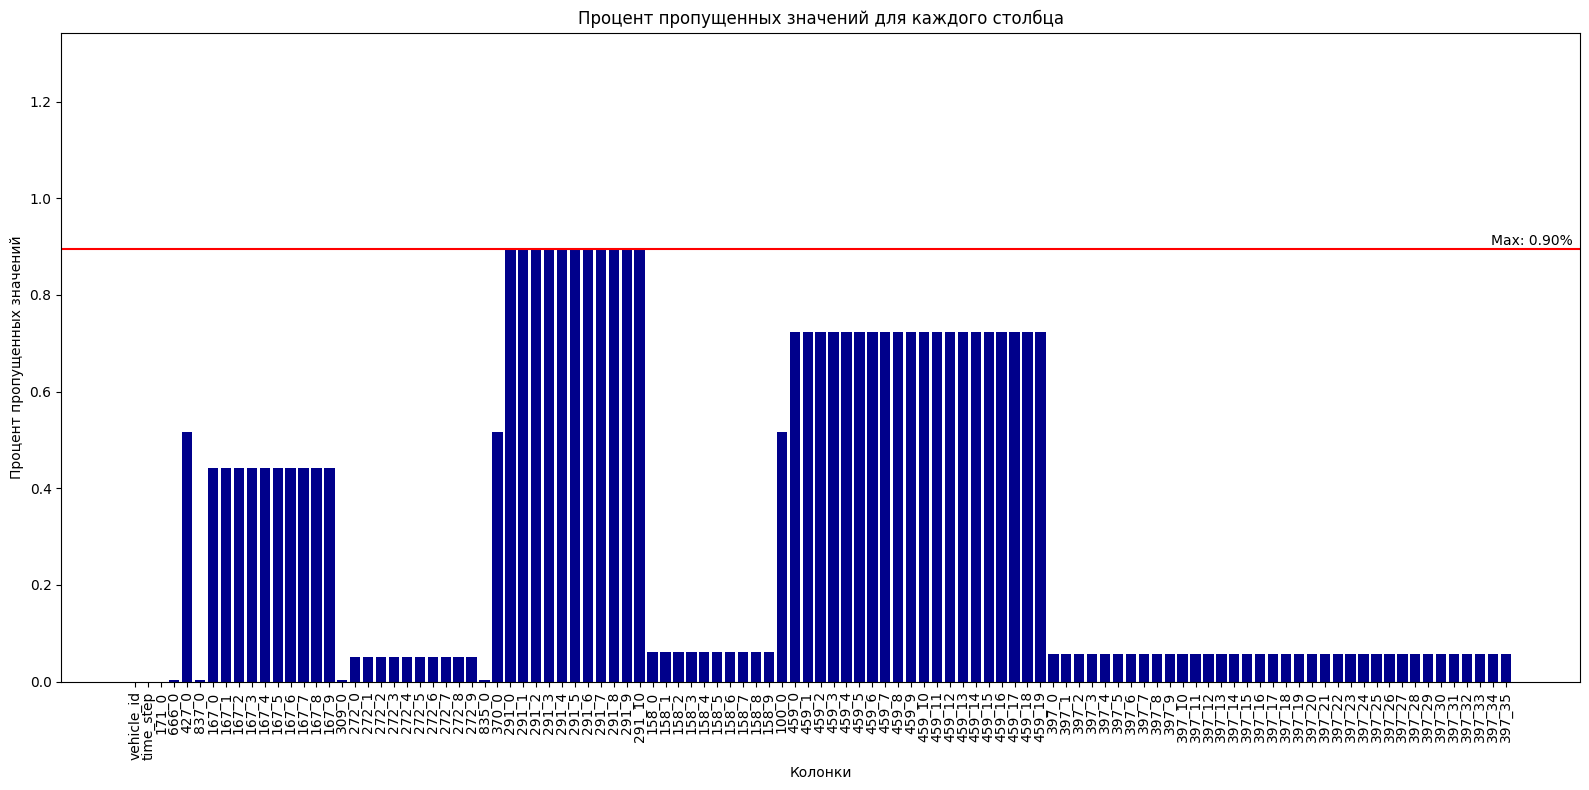

In [ ]:
missing_persent = df_operational_readouts_te.isna().mean() * 100

plt.figure(figsize=(16, 8))
plt.bar(missing_persent.index, missing_persent.values, color="darkblue")
plt.xticks(rotation=90)
plt.xlabel("Колонки")
plt.ylabel("Процент пропущенных значений")
plt.title("Процент пропущенных значений для каждого столбца")
plt.tight_layout()
plt.ylim(0, missing_persent.max()*1.5)
plt.axhline(y=missing_persent.max(), color="red")
plt.text(x=len(missing_persent) * 0.98, y=missing_persent.max()*1.01, s=f"Max: {missing_persent.max():.2f}%")
plt.show()

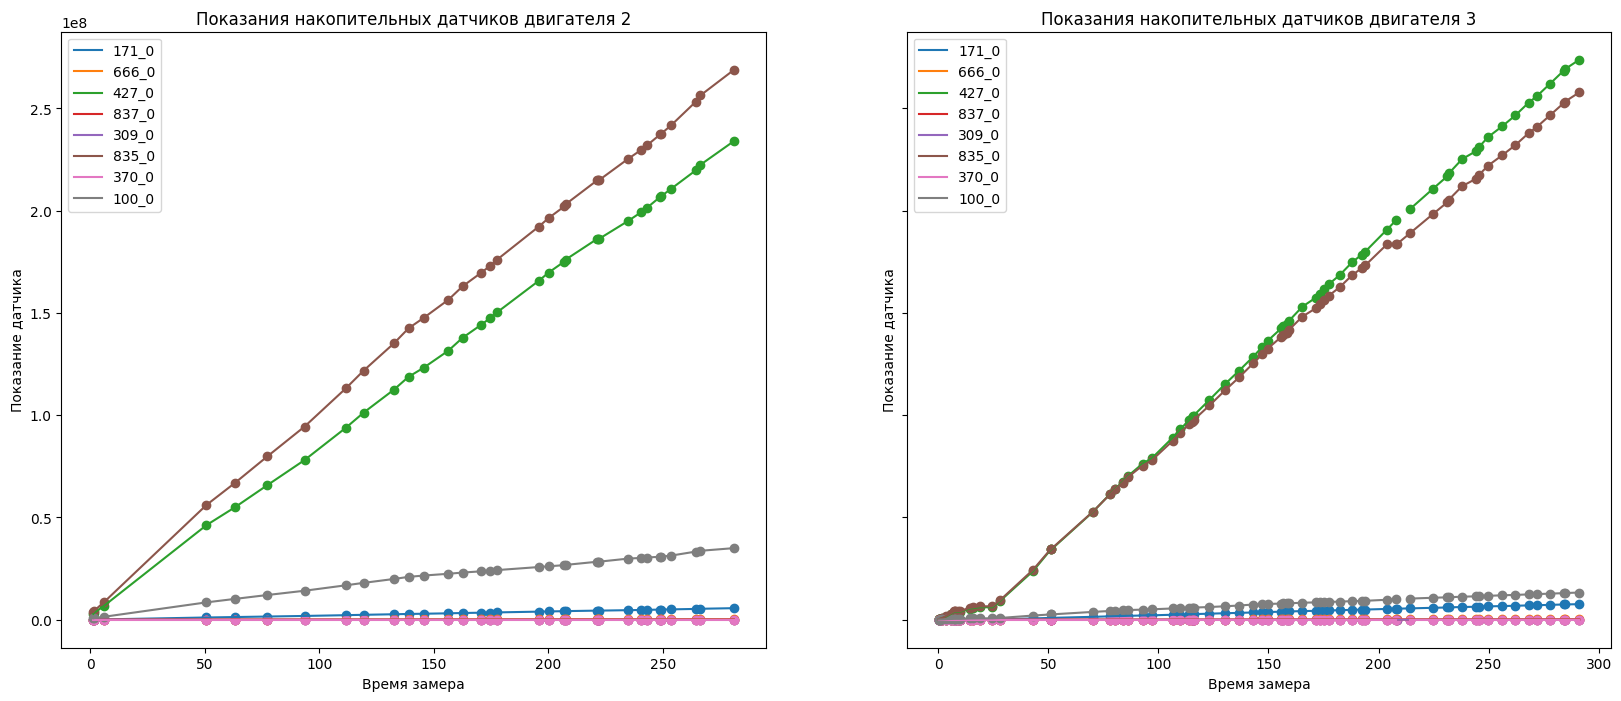

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8), sharey=True)
for i, vehicle_id in enumerate(df_operational_readouts_tr["vehicle_id"].unique()[1:3]):

    vehicle_data = df_operational_readouts_tr[df_operational_readouts_tr["vehicle_id"] == vehicle_id]

    for col in ["171_0", "666_0", "427_0", "837_0", "309_0", "835_0", "370_0", "100_0"]:
        if not col.endswith("_0"):
            continue
        ax[i].plot(vehicle_data["time_step"], vehicle_data[col], label=col)
        ax[i].scatter(vehicle_data["time_step"], vehicle_data[col])
        ax[i].legend()
        ax[i].set_title(f"Показания накопительных датчиков двигателя {vehicle_id}")
        ax[i].set_xlabel("Время замера")
        ax[i].set_ylabel("Показание датчика")

plt.show()

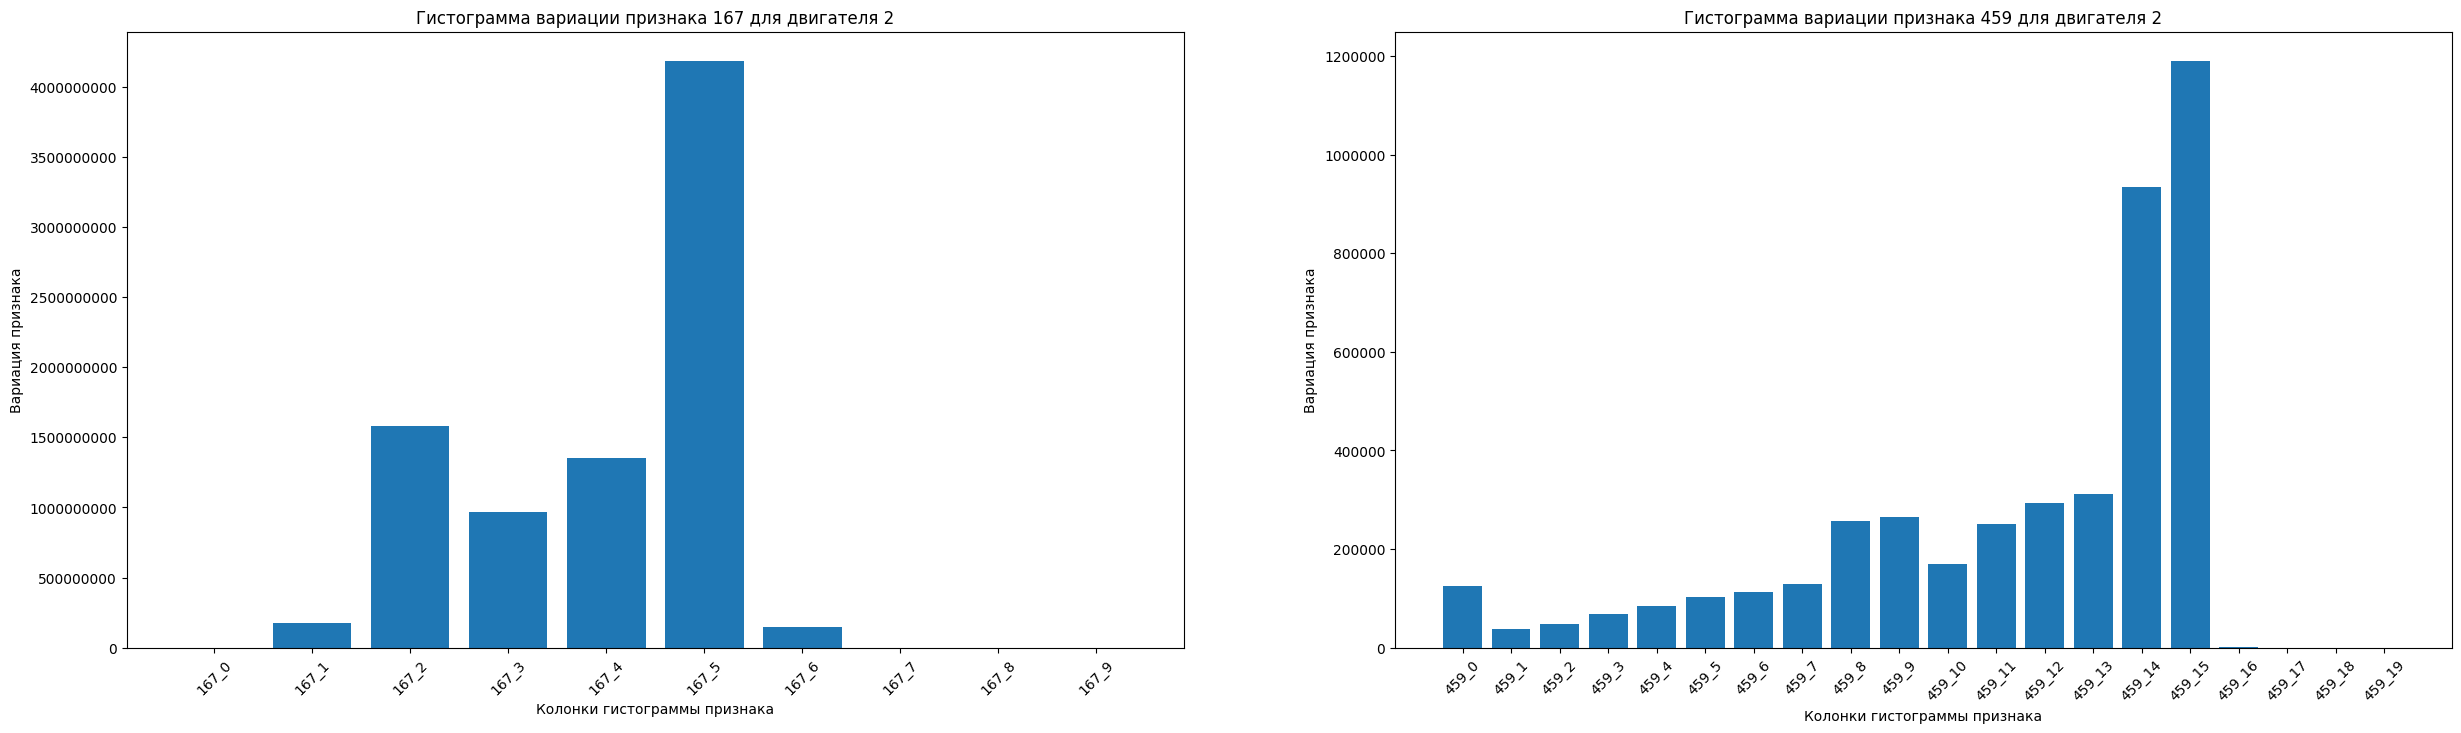

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(30, 8))
vehicle_id = 2
vehicle_data = df_operational_readouts_tr[df_operational_readouts_tr["vehicle_id"] == vehicle_id]
сols = ["167", "459"]
for i, c in enumerate(сols):
    hist_cols = [col for col in vehicle_data.columns if col.startswith(c)]
    ax[i].bar(hist_cols, vehicle_data[hist_cols].sum())
    ax[i].set_title(f"Гистограмма вариации признака {c} для двигателя {vehicle_id}")
    ax[i].set_xlabel("Колонки гистограммы признака")
    ax[i].set_ylabel("Вариация признака")
    ax[i].ticklabel_format(style='plain', axis='y')
    ax[i].set_xticks(ax[i].get_xticks())
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)
plt.show()

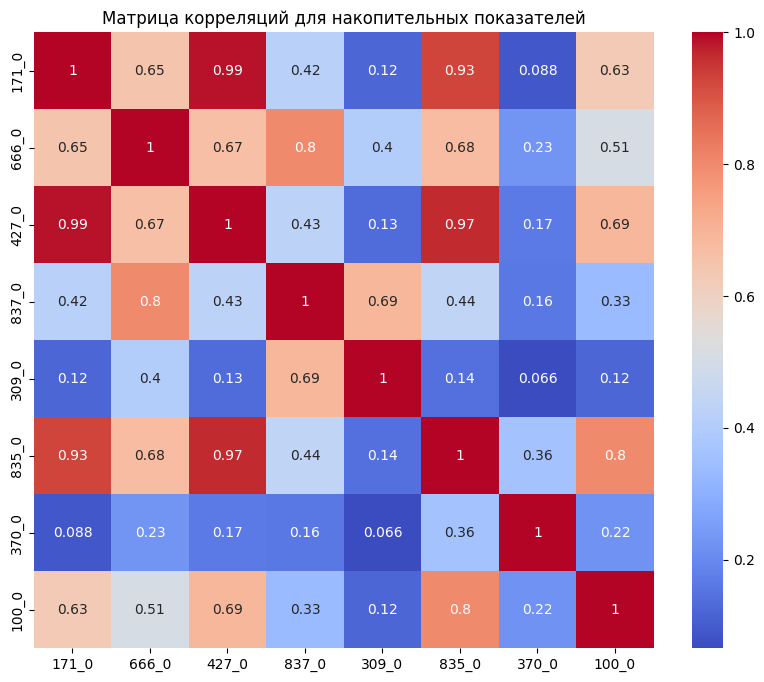

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_operational_readouts_tr[["171_0", "666_0", "427_0", "837_0", "309_0", "835_0", "370_0", "100_0"]].corr(), annot=True, cmap="coolwarm")
plt.title("Матрица корреляций для накопительных показателей")
plt.show()

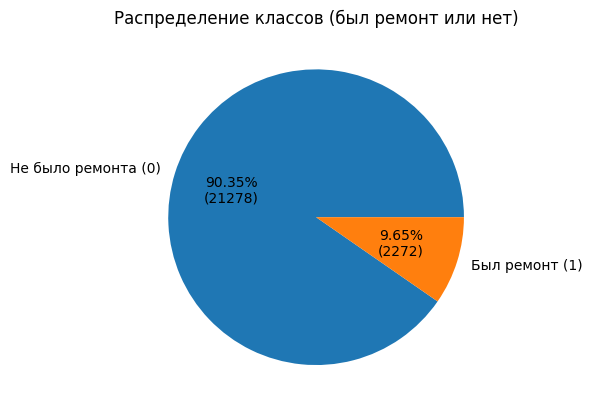

In [ ]:
classes_vc = df_tte_tr["in_study_repair"].value_counts()

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{p:.2f}%\n({v:d})'.format(p=pct,v=val)
    return my_autopct

plt.pie(
    classes_vc,
    labels=["Не было ремонта (0)", "Был ремонт (1)"],
    autopct=make_autopct(classes_vc),
)
# plt.legend(loc="lower left")
plt.title("Распределение классов (был ремонт или нет)")
plt.show()

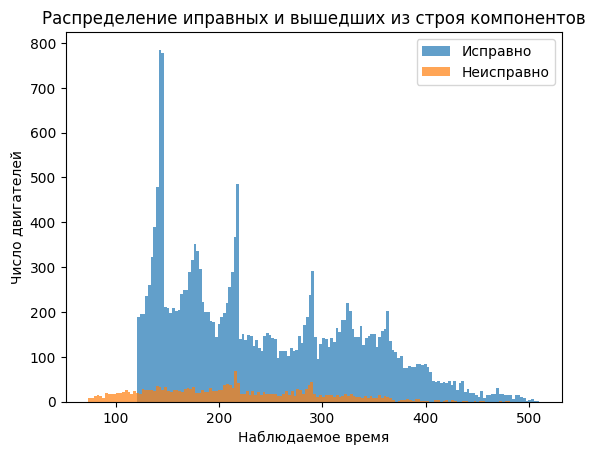

In [ ]:
plt.title("Распределение иправных и вышедших из строя компонентов")
plt.xlabel("Наблюдаемое время")
plt.ylabel("Число двигателей")
plt.hist(df_tte_tr[df_tte_tr["in_study_repair"] == 0]["length_of_study_time_step"], bins=150, alpha=0.7, label="Исправно")
plt.hist(df_tte_tr[df_tte_tr["in_study_repair"] == 1]["length_of_study_time_step"], bins=150, alpha=0.7, label="Неисправно")
plt.legend()
plt.show()

In [ ]:
df_operational_readouts_tr[df_operational_readouts_tr["vehicle_id"] == 3053]

,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,...,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35
140452,3053,11.2,156765.0,4375.0,5532604.0,872.0,3315.0,512130.0,752130.0,720135.0,...,67133.0,3156.0,356.0,4.0,181.0,34696.0,75412.0,10080.0,1540.0,20.0
140453,3053,16.8,345840.0,12677.0,12291191.0,3224.0,3315.0,943081.0,1965450.0,1584495.0,...,153953.0,7473.0,972.0,32.0,501.0,65604.0,183185.0,28345.0,3798.0,88.0
140454,3053,44.2,1136340.0,50001.0,40160967.0,20160.0,3315.0,2103901.0,5109856.0,3565576.0,...,478290.0,23774.0,3681.0,56.0,1709.0,198216.0,660870.0,108553.0,13222.0,96.0
140455,3053,50.6,1351200.0,59367.0,47658116.0,22832.0,3315.0,2512276.0,6091996.0,4200962.0,...,566175.0,28430.0,4286.0,64.0,1937.0,230668.0,784867.0,129521.0,15566.0,100.0
140456,3053,75.0,2080575.0,87500.0,73511185.0,28016.0,3900.0,3896252.0,11694827.0,7005647.0,...,925119.0,49050.0,6551.0,80.0,3185.0,347584.0,1193043.0,196245.0,23610.0,112.0
140457,3053,76.4,2105895.0,88921.0,74414054.0,28328.0,3900.0,4032242.0,11890952.0,7149273.0,...,937620.0,49552.0,6619.0,80.0,3229.0,351917.0,1210151.0,199837.0,24071.0,112.0
140458,3053,96.0,2725890.0,122045.0,95633715.0,37128.0,3900.0,5439257.0,15967847.0,9102663.0,...,1225580.0,65457.0,11316.0,92.0,4189.0,468909.0,1594180.0,254497.0,34816.0,153.0
140459,3053,112.0,3211080.0,149982.0,112217161.0,48888.0,3900.0,5978207.0,17850422.0,9931623.0,...,1440557.0,74690.0,12801.0,100.0,5113.0,572841.0,1902164.0,289457.0,38500.0,165.0
140460,3053,125.4,3672615.0,174426.0,128004636.0,56640.0,3900.0,6982158.0,19862732.0,10866453.0,...,1663654.0,83606.0,14066.0,108.0,6133.0,663497.0,2159620.0,318702.0,41196.0,189.0
140461,3053,130.6,3821775.0,180208.0,133256322.0,58096.0,3900.0,7400073.0,21082277.0,11445288.0,...,1735458.0,85630.0,14374.0,108.0,6617.0,696182.0,2230340.0,322750.0,41685.0,189.0


In [ ]:
df_tte_tr[df_tte_tr["vehicle_id"] == 3053]

,vehicle_id,length_of_study_time_step,in_study_repair
2147,3053,423.8,0


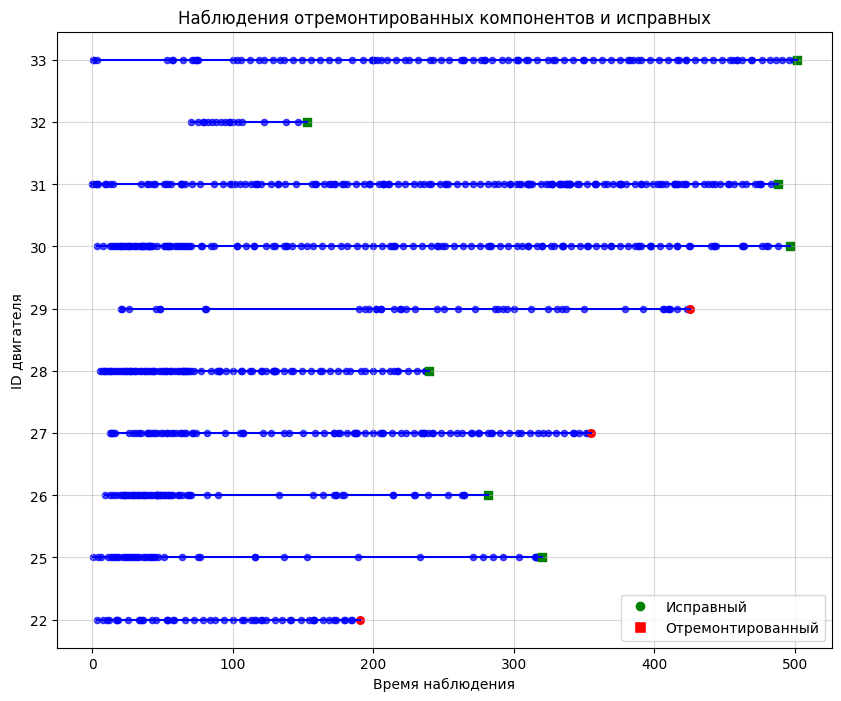

In [ ]:
plt.figure(figsize=(10, 8))
vehicle_ids = df_tte_tr["vehicle_id"].unique()[10:20]
for i, vehicle_id in enumerate(vehicle_ids):
    time_step = df_operational_readouts_tr[df_operational_readouts_tr["vehicle_id"] == vehicle_id]["time_step"]
    is_repair = df_tte_tr[df_tte_tr["vehicle_id"] == vehicle_id]["in_study_repair"]
    length_of_time_steps = df_tte_tr[df_tte_tr["vehicle_id"] == vehicle_id]["length_of_study_time_step"]
    plt.plot([time_step.values[0], length_of_time_steps.values[0]], [i, i], color="blue")
    plt.scatter(time_step, [i for _ in range(len(time_step))], color="blue", s=20, alpha=0.7)
    color = "red" if is_repair.values[0] else "green"
    marker = "o" if is_repair.values[0] else "s"
    plt.scatter([length_of_time_steps.values[0]], [i], color=color, marker=marker, s=30)

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Исправный'),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='red', markersize=8, label='Отремонтированный'),
]

plt.yticks(range(len(vehicle_ids)), vehicle_ids)
plt.xlabel("Время наблюдения")
plt.ylabel("ID двигателя")
plt.title("Наблюдения отремонтированных компонентов и исправных")
plt.grid(True, alpha=0.5)
plt.legend(handles=legend_elements)
plt.show()

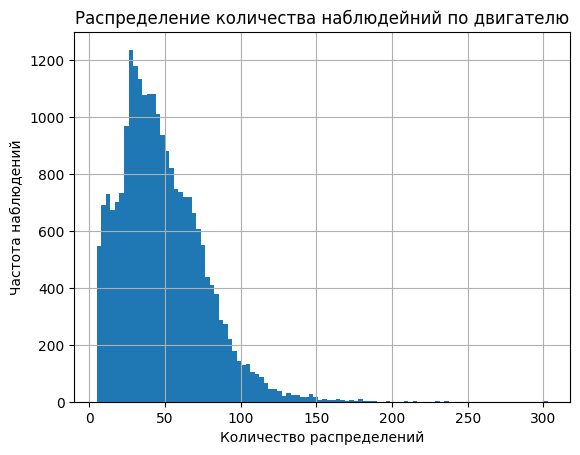

In [ ]:
df_operational_readouts_tr[["vehicle_id"]].value_counts().hist(bins=100)
plt.title("Распределение количества наблюдейний по двигателю")
plt.xlabel("Количество распределений")
plt.ylabel("Частота наблюдений")
plt.show()

In [ ]:
df_specifications_tr[f"Spec_0"].nunique()

3

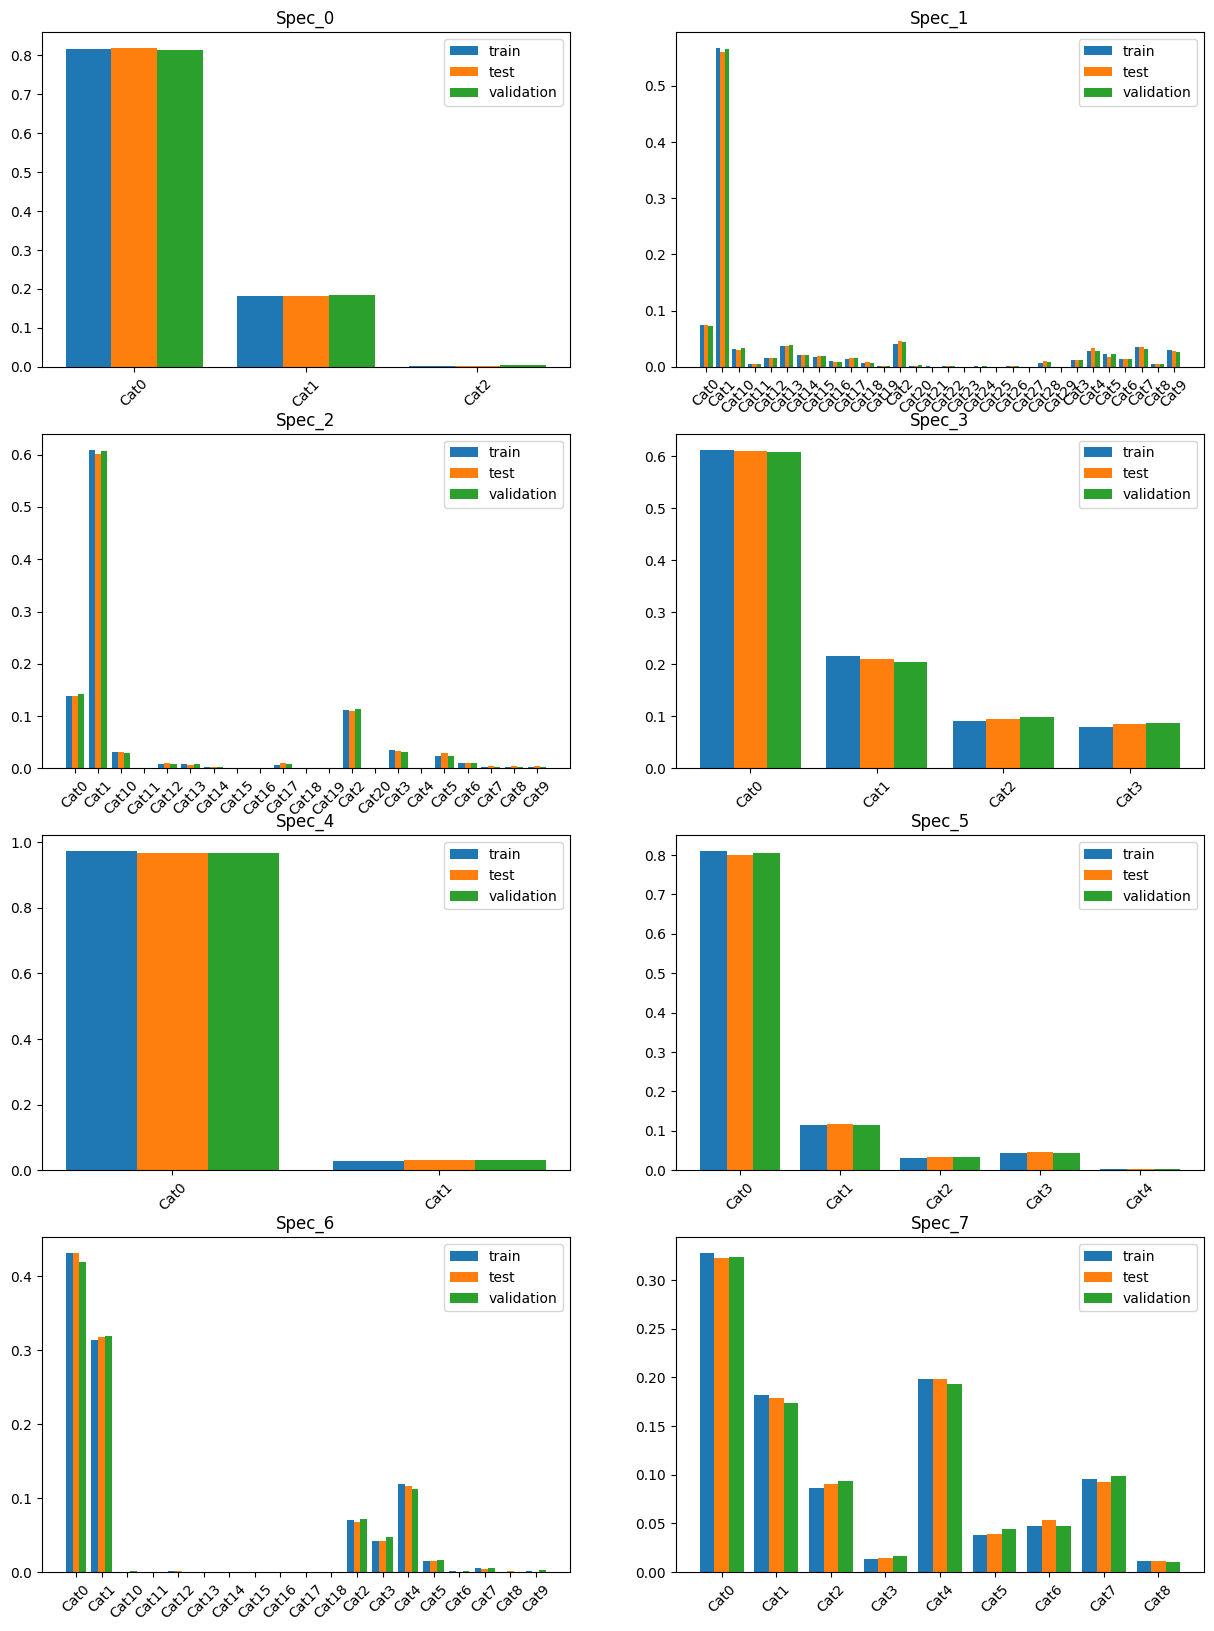

In [ ]:
fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))

spec = 0
for i in range(4):
    for j in range(2):
        col = f"Spec_{spec}"
        all_cats = sorted(
            set(df_specifications_tr[col].dropna().unique())
            | set(df_specifications_te[col].dropna().unique())
            | set(df_specifications_va[col].dropna().unique())
        )
        n_cats = len(all_cats)
        x = np.arange(n_cats) * 3
        vc_tr = df_specifications_tr[col].value_counts(normalize=True).reindex(all_cats, fill_value=0)
        vc_te = df_specifications_te[col].value_counts(normalize=True).reindex(all_cats, fill_value=0)
        vc_va = df_specifications_va[col].value_counts(normalize=True).reindex(all_cats, fill_value=0)
        ax[i][j].bar(x - 0.8, vc_tr, label="train")
        ax[i][j].bar(x, vc_te, label="test")
        ax[i][j].bar(x + 0.8, vc_va, label="validation")
        ax[i][j].set_xticks(x, all_cats, rotation=45)
        ax[i][j].legend()
        ax[i][j].set_title(col)
        spec += 1

plt.show()


Проверю, не коррелирует ли отсутствие значений с неисправностью в компоненте

In [ ]:
failure_vids = df_tte_tr[df_tte_tr["in_study_repair"] == 1]["vehicle_id"].unique()
health_vids = df_tte_tr[df_tte_tr["in_study_repair"] == 0]["vehicle_id"].unique()

In [ ]:
health_data = df_operational_readouts_tr[df_operational_readouts_tr["vehicle_id"].isin(health_vids)]
failure_data = df_operational_readouts_tr[df_operational_readouts_tr["vehicle_id"].isin(failure_vids)]

In [ ]:
diff = health_data.isna().mean() * 100 - failure_data.isna().mean() * 100
with pd.option_context('display.max_rows', None):
    print(diff.abs().sort_values(ascending=False)[:10])

100_0    0.073685
370_0    0.073390
427_0    0.073035
167_3    0.071867
167_4    0.071867
167_1    0.071867
167_9    0.071867
167_6    0.071867
167_7    0.071867
167_5    0.071867
dtype: float64


Разница в долях отсутствующих значений у здоровых и отремонтированных машин < 0.08%

In [ ]:
diff = (failure_data.sort_values(["vehicle_id", "time_step"])
    .groupby("vehicle_id")
    .tail(10)
    .isna().mean() * 100) - failure_data.isna().mean() * 100
with pd.option_context('display.max_rows', None):
    print(diff.abs().sort_values(ascending=False)[:10])

291_1     0.457397
291_3     0.457397
291_0     0.457397
291_10    0.457397
291_9     0.457397
291_8     0.457397
291_2     0.457397
291_4     0.457397
291_5     0.457397
291_7     0.457397
dtype: float64


Разница в долях отсутствующих значений в последних 10 наблюдениях и по всей истории у отремонтированных машин < 0.5%

In [ ]:
diff = (failure_data.sort_values(["vehicle_id", "time_step"])
    .groupby("vehicle_id")
    .tail(10)
    .isna().mean() * 100) - health_data.isna().mean() * 100
with pd.option_context('display.max_rows', None):
    print(diff.abs().sort_values(ascending=False)[:10])

291_1     0.430237
291_3     0.430237
291_0     0.430237
291_10    0.430237
291_9     0.430237
291_8     0.430237
291_2     0.430237
291_4     0.430237
291_5     0.430237
291_7     0.430237
dtype: float64


Разница в долях отсутствующих значений в последних 10 наблюдениях отремонтированных машин и исправных < 0.45%

In [4]:
na_cols = df_operational_readouts_tr.isna().sum()[df_operational_readouts_tr.isna().sum() > 0].index
na_cols

Index(['666_0', '427_0', '837_0', '167_0', '167_1', '167_2', '167_3', '167_4',
       '167_5', '167_6',
       ...
       '397_26', '397_27', '397_28', '397_29', '397_30', '397_31', '397_32',
       '397_33', '397_34', '397_35'],
      dtype='str', length=104)

In [ ]:
h_result = []
for vid, group in health_data.groupby("vehicle_id"):
    row = {}
    row["vehicle_id"] = vid
    for col in na_cols:
        is_na = group[col].isna()
        groups = (is_na != is_na.shift()).cumsum()
        row[col] = is_na.groupby(groups).sum().max()
    h_result.append(row)
h_runs = pd.DataFrame(h_result).set_index("vehicle_id")
h_runs

,666_0,427_0,837_0,167_0,167_1,167_2,167_3,167_4,167_5,167_6,...,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35
vehicle_id,,,,,,,,,,,,,,,,,,,,,
0,0,112,0,170,170,170,170,170,170,170,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,24,24,24,24,24,24,24,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,9,9,9,9,9,9,9,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,34,34,34,34,34,34,34,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33639,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
33640,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
33641,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
f_result = []
for vid, group in failure_data.groupby("vehicle_id"):
    row = {}
    row["vehicle_id"] = vid
    for col in na_cols:
        is_na = group[col].isna()
        groups = (is_na != is_na.shift()).cumsum()
        row[col] = is_na.groupby(groups).sum().max()
    f_result.append(row)
f_runs = pd.DataFrame(f_result).set_index("vehicle_id")
f_runs

,666_0,427_0,837_0,167_0,167_1,167_2,167_3,167_4,167_5,167_6,...,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35
vehicle_id,,,,,,,,,,,,,,,,,,,,,
22,0,0,0,51,51,51,51,51,51,51,...,0,0,0,0,0,0,0,0,0,0
27,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
29,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
52,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
61,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33462,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
33465,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
33467,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
comparison = pd.DataFrame(
    {
        "health_mean": h_runs.mean(),
        "failure_mean": f_runs.mean(),
        "health_max": h_runs.max(),
        "failure_max": f_runs.max(),
        "health_median": h_runs.median(),
        "failure_median": f_runs.median(),
    }
)

comparison["diff_mean"] = comparison["health_mean"] - comparison["failure_mean"]
comparison["diff_max"] = comparison["health_max"] - comparison["failure_max"]
comparison["diff_median"] = comparison["health_median"] - comparison["failure_median"]

comparison.sort_values("diff_mean", ascending=False, key=abs)

,health_mean,failure_mean,health_max,failure_max,health_median,failure_median,diff_mean,diff_max,diff_median
459_0,0.296127,0.245158,82,16,0.0,0.0,0.050969,66,0.0
459_1,0.296127,0.245158,82,16,0.0,0.0,0.050969,66,0.0
459_2,0.296127,0.245158,82,16,0.0,0.0,0.050969,66,0.0
459_3,0.296127,0.245158,82,16,0.0,0.0,0.050969,66,0.0
459_4,0.296127,0.245158,82,16,0.0,0.0,0.050969,66,0.0
...,...,...,...,...,...,...,...,...,...
272_5,0.021290,0.021567,14,1,0.0,0.0,-0.000277,13,0.0
272_3,0.021290,0.021567,14,1,0.0,0.0,-0.000277,13,0.0
837_0,0.001598,0.001761,2,1,0.0,0.0,-0.000163,1,0.0
309_0,0.001457,0.001320,2,1,0.0,0.0,0.000136,1,0.0


Итого гипотеза зависимости поломки от дропаутов проверена тремяя способами доля пропусков в среднем по истории, в последних записях перед ремонтом и по длине подряд идущих пропусков.

По всем трём разницы либо нет, либо разница противоположна гипотезе и у здоровых машин более длинные дропауты, чем у поломанных.

Нет оснований полагать, что отсутствие логирования коррелирует с приблежением поломки.


# Подготовка данных

Заполнение пропусков

In [ ]:
df_operational_readouts_tr[df_operational_readouts_tr.isna().any(axis=1)]

,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,...,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35
2,0,19.6,331635.0,14525.0,13683604.0,2600.0,NaN,NaN,NaN,NaN,...,142900.0,19263.0,2441.0,12.0,1420.0,204832.0,313485.0,106464.0,19306.0,452.0
3,0,20.2,354975.0,15015.0,14540449.0,2616.0,NaN,NaN,NaN,NaN,...,150565.0,19832.0,2522.0,12.0,1444.0,211688.0,318901.0,107745.0,19406.0,453.0
4,0,21.0,365550.0,15295.0,14966985.0,2720.0,NaN,NaN,NaN,NaN,...,155913.0,20573.0,2562.0,12.0,1445.0,213956.0,323997.0,109514.0,19535.0,454.0
5,0,28.0,542490.0,21063.0,21590525.0,3280.0,NaN,NaN,NaN,NaN,...,212929.0,25143.0,3156.0,16.0,2074.0,283016.0,389593.0,127362.0,21347.0,458.0
6,0,28.6,568185.0,21924.0,22549208.0,3337.0,NaN,NaN,NaN,NaN,...,220951.0,25793.0,3262.0,20.0,2114.0,294328.0,398761.0,129167.0,21527.0,458.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1121996,33621,66.6,1539675.0,35077.0,59122416.0,7738.0,13680.0,3906077.0,6377281.0,5170022.0,...,513383.0,45964.0,5913.0,12.0,11647.0,199652.0,372776.0,82649.0,8215.0,88.0
1122018,33622,66.6,2131635.0,57677.0,72974771.0,8850.0,6452.0,2995531.0,8534029.0,6879079.0,...,430031.0,30658.0,5951.0,68.0,9591.0,130740.0,377391.0,86828.0,12623.0,173.0
1122027,33622,129.6,3862335.0,93407.0,NaN,15770.0,13909.0,5844451.0,16512891.0,12120442.0,...,697228.0,53620.0,9278.0,92.0,16885.0,191164.0,590732.0,140681.0,18648.0,185.0
1122260,33635,65.6,1028205.0,12726.0,35411531.0,6530.0,301.0,1344377.0,2817675.0,1318741.0,...,216536.0,9070.0,893.0,4.0,1596.0,47445.0,69377.0,12091.0,944.0,36.0


In [ ]:
df_operational_readouts_tr.shape

(1122452, 107)

In [ ]:
vid_na = df_operational_readouts_tr[df_operational_readouts_tr.isna().any(axis=1)]["vehicle_id"].unique()
df_operational_readouts_tr[~df_operational_readouts_tr["vehicle_id"].isin(vid_na)]

,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,...,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35
172,2,1.4,65520.0,2226.0,2891746.0,424.0,0.0,811605.0,1644061.0,560460.0,...,22516.0,1524.0,232.0,4.0,337.0,12089.0,10388.0,2413.0,1081.0,88.0
173,2,1.6,73215.0,2401.0,3221614.0,488.0,0.0,824430.0,1845031.0,638370.0,...,24450.0,1661.0,256.0,4.0,377.0,13125.0,11100.0,2609.0,1110.0,92.0
174,2,6.0,156150.0,5656.0,6727292.0,944.0,2776.0,1051575.0,3685576.0,1410405.0,...,62722.0,3778.0,648.0,16.0,873.0,33321.0,29052.0,6805.0,2379.0,96.0
175,2,50.8,1091040.0,73703.0,46242922.0,18216.0,5912.0,1935420.0,14616121.0,10103265.0,...,470495.0,33330.0,6527.0,128.0,4262.0,232677.0,345040.0,85935.0,22203.0,449.0
176,2,63.4,1310445.0,92428.0,55111815.0,20616.0,5912.0,2314425.0,18313081.0,12042046.0,...,558799.0,39695.0,7932.0,156.0,4879.0,274641.0,432085.0,109379.0,28767.0,593.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1122447,33643,101.0,2136810.0,41412.0,81068654.0,10365.0,843.0,6408272.0,10964376.0,6092347.0,...,727848.0,34448.0,6540.0,36.0,19500.0,612343.0,626033.0,100155.0,17033.0,24.0
1122448,33643,107.0,2283285.0,44660.0,86639835.0,12317.0,843.0,6596477.0,12358026.0,6721702.0,...,780576.0,37488.0,6964.0,40.0,20484.0,652688.0,670517.0,107367.0,18901.0,24.0
1122449,33643,113.8,2462865.0,48370.0,93439419.0,13910.0,843.0,6669542.0,12830421.0,7415497.0,...,837953.0,40050.0,7524.0,44.0,21688.0,698824.0,722453.0,115851.0,21237.0,28.0
1122450,33643,119.8,2627250.0,51101.0,99682931.0,14854.0,843.0,7074468.0,13604706.0,7747492.0,...,898070.0,42866.0,7992.0,48.0,22732.0,757856.0,777630.0,123155.0,22357.0,32.0


In [ ]:
df_operational_readouts_tr[df_operational_readouts_tr["vehicle_id"] == 0]

,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,...,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35
0,0,11.2,167985.0,10787.0,7413813.0,2296.0,4110.0,1296420.0,1628265.0,630345.0,...,95728.0,15609.0,1984.0,8.0,784.0,150228.0,261904.0,93172.0,17874.0,452.0
1,0,11.4,167985.0,10787.0,7413813.0,2296.0,4111.0,1302855.0,1628265.0,630345.0,...,95729.0,15610.0,1984.0,8.0,784.0,150228.0,261905.0,93172.0,17874.0,452.0
2,0,19.6,331635.0,14525.0,13683604.0,2600.0,NaN,NaN,NaN,NaN,...,142900.0,19263.0,2441.0,12.0,1420.0,204832.0,313485.0,106464.0,19306.0,452.0
3,0,20.2,354975.0,15015.0,14540449.0,2616.0,NaN,NaN,NaN,NaN,...,150565.0,19832.0,2522.0,12.0,1444.0,211688.0,318901.0,107745.0,19406.0,453.0
4,0,21.0,365550.0,15295.0,14966985.0,2720.0,NaN,NaN,NaN,NaN,...,155913.0,20573.0,2562.0,12.0,1445.0,213956.0,323997.0,109514.0,19535.0,454.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,0,494.6,9934035.0,362143.0,NaN,41212.0,NaN,NaN,NaN,NaN,...,3804537.0,237500.0,42504.0,363.0,35573.0,3440243.0,4152300.0,995254.0,134394.0,775.0
168,0,496.0,9954120.0,362836.0,NaN,41292.0,NaN,NaN,NaN,NaN,...,3815225.0,238088.0,42624.0,363.0,35597.0,3448407.0,4161624.0,997822.0,134702.0,775.0
169,0,500.0,10045560.0,366525.0,NaN,41397.0,NaN,NaN,NaN,NaN,...,3860593.0,240908.0,43157.0,363.0,35963.0,3479311.0,4209317.0,1007502.0,136190.0,783.0
170,0,501.4,10075605.0,367918.0,NaN,41437.0,NaN,NaN,NaN,NaN,...,3874693.0,241592.0,43341.0,367.0,36043.0,3491940.0,4228133.0,1011070.0,136883.0,791.0


In [ ]:
df_na = df_operational_readouts_tr.groupby('vehicle_id').apply(lambda g: g.notna().mean() * 100)
df_na

/tmp/ipykernel_71773/2803363641.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_na = df_operational_readouts_tr.groupby('vehicle_id').apply(lambda g: g.notna().mean() * 100)


,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,...,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35
vehicle_id,,,,,,,,,,,,,,,,,,,,,
0,100.0,100.0,100.0,100.0,34.883721,100.0,1.162791,1.162791,1.162791,1.162791,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
2,100.0,100.0,100.0,100.0,100.000000,100.0,100.000000,100.000000,100.000000,100.000000,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
3,100.0,100.0,100.0,100.0,98.591549,100.0,66.197183,66.197183,66.197183,66.197183,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
4,100.0,100.0,100.0,100.0,100.000000,100.0,47.058824,47.058824,47.058824,47.058824,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
5,100.0,100.0,100.0,100.0,100.000000,100.0,22.727273,22.727273,22.727273,22.727273,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33639,100.0,100.0,100.0,100.0,100.000000,100.0,100.000000,100.000000,100.000000,100.000000,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
33640,100.0,100.0,100.0,100.0,100.000000,100.0,100.000000,100.000000,100.000000,100.000000,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
33641,100.0,100.0,100.0,100.0,100.000000,100.0,100.000000,100.000000,100.000000,100.000000,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


In [ ]:
df_na[((df_na <= 5)).any(axis=1)]

,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,...,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35
vehicle_id,,,,,,,,,,,,,,,,,,,,,
0,100.0,100.0,100.0,100.0,34.883721,100.0,1.162791,1.162791,1.162791,1.162791,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
15,100.0,100.0,100.0,100.0,100.000000,100.0,1.785714,1.785714,1.785714,1.785714,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
22,100.0,100.0,100.0,100.0,100.000000,100.0,0.000000,0.000000,0.000000,0.000000,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
5075,100.0,100.0,100.0,100.0,3.100775,100.0,100.000000,100.000000,100.000000,100.000000,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
5317,100.0,100.0,100.0,100.0,100.000000,100.0,4.494382,4.494382,4.494382,4.494382,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
5916,100.0,100.0,100.0,100.0,3.846154,100.0,100.000000,100.000000,100.000000,100.000000,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
6902,100.0,100.0,100.0,100.0,4.109589,100.0,100.000000,100.000000,100.000000,100.000000,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
16955,100.0,100.0,100.0,100.0,100.000000,100.0,3.846154,3.846154,3.846154,3.846154,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
18359,100.0,100.0,100.0,100.0,3.571429,100.0,100.000000,100.000000,100.000000,100.000000,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


In [5]:
df_operational_readouts_tr_copy = df_operational_readouts_tr.copy()
df_operational_readouts_tr_copy[na_cols] = df_operational_readouts_tr.groupby("vehicle_id")[na_cols].ffill(limit=3)

def steps_since_obs(c):
    return c.groupby(c.notna().cumsum()).cumcount()

new_cols = {}

for c in na_cols:
    if c.endswith("_0"):
        new_cols[f"{c}_steps_since_obs"] = df_operational_readouts_tr.groupby("vehicle_id")[c].transform(steps_since_obs)


df_operational_readouts_tr_copy = pd.concat([df_operational_readouts_tr_copy, pd.DataFrame(new_cols)], axis=1)
df_operational_readouts_tr_copy

,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,...,167_0_steps_since_obs,309_0_steps_since_obs,272_0_steps_since_obs,835_0_steps_since_obs,370_0_steps_since_obs,291_0_steps_since_obs,158_0_steps_since_obs,100_0_steps_since_obs,459_0_steps_since_obs,397_0_steps_since_obs
0,0,11.2,167985.0,10787.0,7413813.0,2296.0,4110.0,1296420.0,1628265.0,630345.0,...,0,0,0,0,0,0,0,0,0,0
1,0,11.4,167985.0,10787.0,7413813.0,2296.0,4111.0,1302855.0,1628265.0,630345.0,...,0,0,0,0,0,0,0,0,0,0
2,0,19.6,331635.0,14525.0,13683604.0,2600.0,4111.0,1302855.0,1628265.0,630345.0,...,1,0,0,0,0,0,0,0,0,0
3,0,20.2,354975.0,15015.0,14540449.0,2616.0,4111.0,1302855.0,1628265.0,630345.0,...,2,0,0,0,0,0,0,0,0,0
4,0,21.0,365550.0,15295.0,14966985.0,2720.0,4111.0,1302855.0,1628265.0,630345.0,...,3,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1122447,33643,101.0,2136810.0,41412.0,81068654.0,10365.0,843.0,6408272.0,10964376.0,6092347.0,...,0,0,0,0,0,0,0,0,0,0
1122448,33643,107.0,2283285.0,44660.0,86639835.0,12317.0,843.0,6596477.0,12358026.0,6721702.0,...,0,0,0,0,0,0,0,0,0,0
1122449,33643,113.8,2462865.0,48370.0,93439419.0,13910.0,843.0,6669542.0,12830421.0,7415497.0,...,0,0,0,0,0,0,0,0,0,0
1122450,33643,119.8,2627250.0,51101.0,99682931.0,14854.0,843.0,7074468.0,13604706.0,7747492.0,...,0,0,0,0,0,0,0,0,0,0


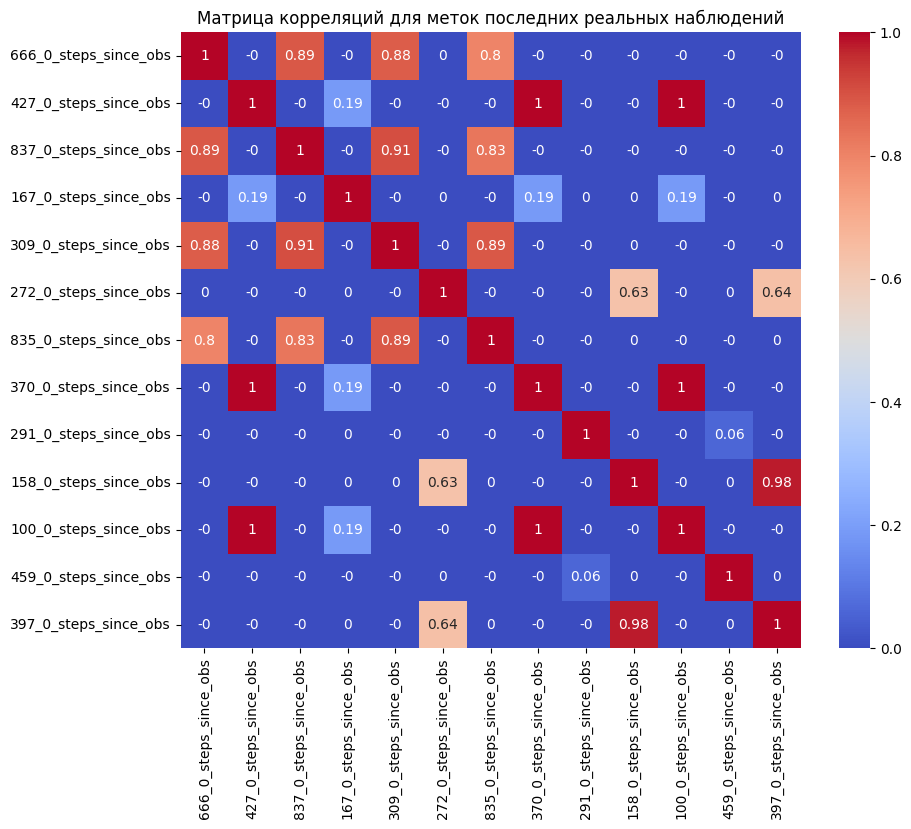

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_operational_readouts_tr_copy[[col for col in df_operational_readouts_tr_copy.columns if col.endswith("obs")]].corr().round(2), annot=True, cmap="coolwarm")
plt.title("Матрица корреляций для меток последних реальных наблюдений")
plt.show()

Заполню оставшиеся пропуски значением выходящим за распределение показателей и создам флаг о наличии/отсутствии данных в оригинальном датафрейме

In [6]:
new_comumns = {}
for col in na_cols:
    new_comumns[f"has_{col}"] =  df_operational_readouts_tr[col].notna().astype(int)
    df_operational_readouts_tr_copy[col] = df_operational_readouts_tr_copy[col].fillna(-1)
df_operational_readouts_tr_copy = pd.concat([df_operational_readouts_tr_copy, pd.DataFrame(new_comumns)], axis=1)
df_operational_readouts_tr_copy

,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,...,has_397_26,has_397_27,has_397_28,has_397_29,has_397_30,has_397_31,has_397_32,has_397_33,has_397_34,has_397_35
0,0,11.2,167985.0,10787.0,7413813.0,2296.0,4110.0,1296420.0,1628265.0,630345.0,...,1,1,1,1,1,1,1,1,1,1
1,0,11.4,167985.0,10787.0,7413813.0,2296.0,4111.0,1302855.0,1628265.0,630345.0,...,1,1,1,1,1,1,1,1,1,1
2,0,19.6,331635.0,14525.0,13683604.0,2600.0,4111.0,1302855.0,1628265.0,630345.0,...,1,1,1,1,1,1,1,1,1,1
3,0,20.2,354975.0,15015.0,14540449.0,2616.0,4111.0,1302855.0,1628265.0,630345.0,...,1,1,1,1,1,1,1,1,1,1
4,0,21.0,365550.0,15295.0,14966985.0,2720.0,4111.0,1302855.0,1628265.0,630345.0,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1122447,33643,101.0,2136810.0,41412.0,81068654.0,10365.0,843.0,6408272.0,10964376.0,6092347.0,...,1,1,1,1,1,1,1,1,1,1
1122448,33643,107.0,2283285.0,44660.0,86639835.0,12317.0,843.0,6596477.0,12358026.0,6721702.0,...,1,1,1,1,1,1,1,1,1,1
1122449,33643,113.8,2462865.0,48370.0,93439419.0,13910.0,843.0,6669542.0,12830421.0,7415497.0,...,1,1,1,1,1,1,1,1,1,1
1122450,33643,119.8,2627250.0,51101.0,99682931.0,14854.0,843.0,7074468.0,13604706.0,7747492.0,...,1,1,1,1,1,1,1,1,1,1


Сохраню на диск, потому что оперативки не хватает, чтобы полностью запускать процесс

In [7]:
df_operational_readouts_tr_copy.to_csv("data/train_operational_readouts_full.csv", index=False)

Хочу проверить корреляцию отсутствия наблюдений со спецификациями транспортных средств

In [ ]:
has_col = [col for col in df_operational_readouts_tr_copy.columns if col.startswith("has_")]
df_operational_spec = pd.merge(df_operational_readouts_tr_copy[["vehicle_id", *has_col]], df_specifications_tr, how="left", on="vehicle_id")


In [ ]:
df_operational_spec

,vehicle_id,has_666_0,has_427_0,has_837_0,has_167_0,has_167_1,has_167_2,has_167_3,has_167_4,has_167_5,...,has_397_34,has_397_35,Spec_0,Spec_1,Spec_2,Spec_3,Spec_4,Spec_5,Spec_6,Spec_7
0,0,1,1,1,1,1,1,1,1,1,...,1,1,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0
1,0,1,1,1,1,1,1,1,1,1,...,1,1,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0
2,0,1,1,1,0,0,0,0,0,0,...,1,1,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0
3,0,1,1,1,0,0,0,0,0,0,...,1,1,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0
4,0,1,1,1,0,0,0,0,0,0,...,1,1,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1122447,33643,1,1,1,1,1,1,1,1,1,...,1,1,Cat0,Cat0,Cat2,Cat0,Cat0,Cat0,Cat1,Cat4
1122448,33643,1,1,1,1,1,1,1,1,1,...,1,1,Cat0,Cat0,Cat2,Cat0,Cat0,Cat0,Cat1,Cat4
1122449,33643,1,1,1,1,1,1,1,1,1,...,1,1,Cat0,Cat0,Cat2,Cat0,Cat0,Cat0,Cat1,Cat4
1122450,33643,1,1,1,1,1,1,1,1,1,...,1,1,Cat0,Cat0,Cat2,Cat0,Cat0,Cat0,Cat1,Cat4


In [ ]:
corr = pd.concat([pd.get_dummies(df_operational_spec[[spec for spec in df_operational_spec.columns if spec.startswith("Spec")]]), df_operational_spec[has_col]], axis=1).corr()
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(corr)

              Spec_0_Cat0  Spec_0_Cat1  Spec_0_Cat2   Spec_1_Cat0  \
Spec_0_Cat0      1.000000    -0.995672    -0.075482 -1.463999e-01   
Spec_0_Cat1     -0.995672     1.000000    -0.017522  1.478527e-01   
Spec_0_Cat2     -0.075482    -0.017522     1.000000 -1.133468e-02   
Spec_1_Cat0     -0.146400     0.147853    -0.011335  1.000000e+00   
Spec_1_Cat1      0.308238    -0.305505    -0.038267 -3.454360e-01   
Spec_1_Cat10    -0.150660     0.145135     0.063648 -5.727245e-02   
Spec_1_Cat11     0.010356    -0.010147    -0.002552 -2.177345e-02   
Spec_1_Cat12    -0.095529     0.096227    -0.004710 -4.019194e-02   
Spec_1_Cat13    -0.054780     0.055589    -0.007090 -6.049689e-02   
Spec_1_Cat14    -0.029723     0.030274    -0.005047 -4.306706e-02   
Spec_1_Cat15    -0.122522     0.119278     0.038356 -4.158338e-02   
Spec_1_Cat16    -0.089432     0.090007    -0.003569 -3.045403e-02   
Spec_1_Cat17     0.023825    -0.024235     0.003704 -3.536856e-02   
Spec_1_Cat18    -0.071630     0.07

In [ ]:
df_operational_spec.groupby("Spec_0")[has_col].mean()

,has_666_0,has_427_0,has_837_0,has_167_0,has_167_1,has_167_2,has_167_3,has_167_4,has_167_5,has_167_6,...,has_397_26,has_397_27,has_397_28,has_397_29,has_397_30,has_397_31,has_397_32,has_397_33,has_397_34,has_397_35
Spec_0,,,,,,,,,,,,,,,,,,,,,
Cat0,0.999962,0.994183,0.999960,0.997218,0.997218,0.997218,0.997218,0.997218,0.997218,0.997218,...,0.999425,0.999425,0.999425,0.999425,0.999425,0.999425,0.999425,0.999425,0.999425,0.999425
Cat1,0.999976,0.995036,0.999986,0.998434,0.998434,0.998434,0.998434,0.998434,0.998434,0.998434,...,0.999587,0.999587,0.999587,0.999587,0.999587,0.999587,0.999587,0.999587,0.999587,0.999587
Cat2,1.000000,0.957018,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df_operational_spec.groupby("Spec_1")[has_col].mean()

,has_666_0,has_427_0,has_837_0,has_167_0,has_167_1,has_167_2,has_167_3,has_167_4,has_167_5,has_167_6,...,has_397_26,has_397_27,has_397_28,has_397_29,has_397_30,has_397_31,has_397_32,has_397_33,has_397_34,has_397_35
Spec_1,,,,,,,,,,,,,,,,,,,,,
Cat0,0.999960,0.993535,0.999949,0.995848,0.995848,0.995848,0.995848,0.995848,0.995848,0.995848,...,0.999515,0.999515,0.999515,0.999515,0.999515,0.999515,0.999515,0.999515,0.999515,0.999515
Cat1,0.999960,0.994554,0.999958,0.997971,0.997971,0.997971,0.997971,0.997971,0.997971,0.997971,...,0.999395,0.999395,0.999395,0.999395,0.999395,0.999395,0.999395,0.999395,0.999395,0.999395
Cat10,1.000000,0.995600,1.000000,0.996958,0.996958,0.996958,0.996958,0.996958,0.996958,0.996958,...,0.999756,0.999756,0.999756,0.999756,0.999756,0.999756,0.999756,0.999756,0.999756,0.999756
Cat11,1.000000,0.991233,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.997260,0.997260,0.997260,0.997260,0.997260,0.997260,0.997260,0.997260,0.997260,0.997260
Cat12,1.000000,0.995661,1.000000,0.997993,0.997993,0.997993,0.997993,0.997993,0.997993,0.997993,...,0.999349,0.999349,0.999349,0.999349,0.999349,0.999349,0.999349,0.999349,0.999349,0.999349
Cat13,1.000000,0.994087,1.000000,0.998803,0.998803,0.998803,0.998803,0.998803,0.998803,0.998803,...,0.999340,0.999340,0.999340,0.999340,0.999340,0.999340,0.999340,0.999340,0.999340,0.999340
Cat14,0.999905,0.994223,0.999905,0.999574,0.999574,0.999574,0.999574,0.999574,0.999574,0.999574,...,0.999621,0.999621,0.999621,0.999621,0.999621,0.999621,0.999621,0.999621,0.999621,0.999621
Cat15,0.999949,0.993761,1.000000,0.995486,0.995486,0.995486,0.995486,0.995486,0.995486,0.995486,...,0.999746,0.999746,0.999746,0.999746,0.999746,0.999746,0.999746,0.999746,0.999746,0.999746
Cat16,1.000000,0.997561,1.000000,0.999812,0.999812,0.999812,0.999812,0.999812,0.999812,0.999812,...,0.999437,0.999437,0.999437,0.999437,0.999437,0.999437,0.999437,0.999437,0.999437,0.999437


In [ ]:
df_operational_spec.groupby("Spec_2")[has_col].mean()

,has_666_0,has_427_0,has_837_0,has_167_0,has_167_1,has_167_2,has_167_3,has_167_4,has_167_5,has_167_6,...,has_397_26,has_397_27,has_397_28,has_397_29,has_397_30,has_397_31,has_397_32,has_397_33,has_397_34,has_397_35
Spec_2,,,,,,,,,,,,,,,,,,,,,
Cat0,0.999966,0.992406,0.999972,0.995326,0.995326,0.995326,0.995326,0.995326,0.995326,0.995326,...,0.999542,0.999542,0.999542,0.999542,0.999542,0.999542,0.999542,0.999542,0.999542,0.999542
Cat1,0.999958,0.994354,0.999956,0.997849,0.997849,0.997849,0.997849,0.997849,0.997849,0.997849,...,0.999382,0.999382,0.999382,0.999382,0.999382,0.999382,0.999382,0.999382,0.999382,0.999382
Cat10,0.999918,0.994631,0.999945,0.997901,0.997901,0.997901,0.997901,0.997901,0.997901,0.997901,...,0.999864,0.999864,0.999864,0.999864,0.999864,0.999864,0.999864,0.999864,0.999864,0.999864
Cat11,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Cat12,1.000000,0.996096,1.000000,0.999763,0.999763,0.999763,0.999763,0.999763,0.999763,0.999763,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Cat13,1.000000,0.998709,1.000000,0.997903,0.997903,0.997903,0.997903,0.997903,0.997903,0.997903,...,0.999677,0.999677,0.999677,0.999677,0.999677,0.999677,0.999677,0.999677,0.999677,0.999677
Cat14,1.000000,0.998291,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Cat15,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Cat16,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df_operational_spec.groupby("Spec_3")[has_col].mean()

,has_666_0,has_427_0,has_837_0,has_167_0,has_167_1,has_167_2,has_167_3,has_167_4,has_167_5,has_167_6,...,has_397_26,has_397_27,has_397_28,has_397_29,has_397_30,has_397_31,has_397_32,has_397_33,has_397_34,has_397_35
Spec_3,,,,,,,,,,,,,,,,,,,,,
Cat0,0.999958,0.994351,0.999958,0.997712,0.997712,0.997712,0.997712,0.997712,0.997712,0.997712,...,0.999424,0.999424,0.999424,0.999424,0.999424,0.999424,0.999424,0.999424,0.999424,0.999424
Cat1,0.999971,0.994105,0.999971,0.997230,0.997230,0.997230,0.997230,0.997230,0.997230,0.997230,...,0.999383,0.999383,0.999383,0.999383,0.999383,0.999383,0.999383,0.999383,0.999383,0.999383
Cat2,0.999970,0.993922,0.999970,0.996784,0.996784,0.996784,0.996784,0.996784,0.996784,0.996784,...,0.999675,0.999675,0.999675,0.999675,0.999675,0.999675,0.999675,0.999675,0.999675,0.999675
Cat3,0.999988,0.994833,1.000000,0.996714,0.996714,0.996714,0.996714,0.996714,0.996714,0.996714,...,0.999682,0.999682,0.999682,0.999682,0.999682,0.999682,0.999682,0.999682,0.999682,0.999682


In [ ]:
df_operational_spec.groupby("Spec_4")[has_col].mean()


,has_666_0,has_427_0,has_837_0,has_167_0,has_167_1,has_167_2,has_167_3,has_167_4,has_167_5,has_167_6,...,has_397_26,has_397_27,has_397_28,has_397_29,has_397_30,has_397_31,has_397_32,has_397_33,has_397_34,has_397_35
Spec_4,,,,,,,,,,,,,,,,,,,,,
Cat0,0.999964,0.994253,0.999965,0.997417,0.997417,0.997417,0.997417,0.997417,0.997417,0.997417,...,0.999450,0.999450,0.999450,0.999450,0.999450,0.999450,0.999450,0.999450,0.999450,0.999450
Cat1,1.000000,0.996527,1.000000,0.999295,0.999295,0.999295,0.999295,0.999295,0.999295,0.999295,...,0.999799,0.999799,0.999799,0.999799,0.999799,0.999799,0.999799,0.999799,0.999799,0.999799


In [ ]:
df_operational_spec.groupby("Spec_4")[has_col].mean()


,has_666_0,has_427_0,has_837_0,has_167_0,has_167_1,has_167_2,has_167_3,has_167_4,has_167_5,has_167_6,...,has_397_26,has_397_27,has_397_28,has_397_29,has_397_30,has_397_31,has_397_32,has_397_33,has_397_34,has_397_35
Spec_4,,,,,,,,,,,,,,,,,,,,,
Cat0,0.999964,0.994253,0.999965,0.997417,0.997417,0.997417,0.997417,0.997417,0.997417,0.997417,...,0.999450,0.999450,0.999450,0.999450,0.999450,0.999450,0.999450,0.999450,0.999450,0.999450
Cat1,1.000000,0.996527,1.000000,0.999295,0.999295,0.999295,0.999295,0.999295,0.999295,0.999295,...,0.999799,0.999799,0.999799,0.999799,0.999799,0.999799,0.999799,0.999799,0.999799,0.999799


In [ ]:
df_operational_spec.groupby("Spec_5")[has_col].mean()


,has_666_0,has_427_0,has_837_0,has_167_0,has_167_1,has_167_2,has_167_3,has_167_4,has_167_5,has_167_6,...,has_397_26,has_397_27,has_397_28,has_397_29,has_397_30,has_397_31,has_397_32,has_397_33,has_397_34,has_397_35
Spec_5,,,,,,,,,,,,,,,,,,,,,
Cat0,0.999964,0.994289,0.999963,0.997404,0.997404,0.997404,0.997404,0.997404,0.997404,0.997404,...,0.999427,0.999427,0.999427,0.999427,0.999427,0.999427,0.999427,0.999427,0.999427,0.999427
Cat1,0.999958,0.995850,0.999972,0.998019,0.998019,0.998019,0.998019,0.998019,0.998019,0.998019,...,0.999589,0.999589,0.999589,0.999589,0.999589,0.999589,0.999589,0.999589,0.999589,0.999589
Cat2,0.999945,0.990606,0.999945,0.996758,0.996758,0.996758,0.996758,0.996758,0.996758,0.996758,...,0.999279,0.999279,0.999279,0.999279,0.999279,0.999279,0.999279,0.999279,0.999279,0.999279
Cat3,1.000000,0.992016,1.000000,0.996981,0.996981,0.996981,0.996981,0.996981,0.996981,0.996981,...,0.999781,0.999781,0.999781,0.999781,0.999781,0.999781,0.999781,0.999781,0.999781,0.999781
Cat4,1.000000,0.998827,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df_operational_spec.groupby("Spec_6")[has_col].mean()


,has_666_0,has_427_0,has_837_0,has_167_0,has_167_1,has_167_2,has_167_3,has_167_4,has_167_5,has_167_6,...,has_397_26,has_397_27,has_397_28,has_397_29,has_397_30,has_397_31,has_397_32,has_397_33,has_397_34,has_397_35
Spec_6,,,,,,,,,,,,,,,,,,,,,
Cat0,0.999962,0.994040,0.999962,0.996383,0.996383,0.996383,0.996383,0.996383,0.996383,0.996383,...,0.999422,0.999422,0.999422,0.999422,0.999422,0.999422,0.999422,0.999422,0.999422,0.999422
Cat1,0.999956,0.994179,0.999956,0.998356,0.998356,0.998356,0.998356,0.998356,0.998356,0.998356,...,0.999376,0.999376,0.999376,0.999376,0.999376,0.999376,0.999376,0.999376,0.999376,0.999376
Cat10,1.000000,0.895522,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Cat11,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.989247,0.989247,0.989247,0.989247,0.989247,0.989247,0.989247,0.989247,0.989247,0.989247
Cat12,1.000000,0.998733,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Cat13,1.000000,0.996283,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Cat15,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Cat17,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Cat18,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df_operational_spec.groupby("Spec_7")[has_col].mean()


,has_666_0,has_427_0,has_837_0,has_167_0,has_167_1,has_167_2,has_167_3,has_167_4,has_167_5,has_167_6,...,has_397_26,has_397_27,has_397_28,has_397_29,has_397_30,has_397_31,has_397_32,has_397_33,has_397_34,has_397_35
Spec_7,,,,,,,,,,,,,,,,,,,,,
Cat0,0.999942,0.993022,0.999937,0.996812,0.996812,0.996812,0.996812,0.996812,0.996812,0.996812,...,0.999198,0.999198,0.999198,0.999198,0.999198,0.999198,0.999198,0.999198,0.999198,0.999198
Cat1,0.999948,0.990653,0.999956,0.996204,0.996204,0.996204,0.996204,0.996204,0.996204,0.996204,...,0.999296,0.999296,0.999296,0.999296,0.999296,0.999296,0.999296,0.999296,0.999296,0.999296
Cat2,0.999965,0.994227,0.999974,0.995448,0.995448,0.995448,0.995448,0.995448,0.995448,0.995448,...,0.999093,0.999093,0.999093,0.999093,0.999093,0.999093,0.999093,0.999093,0.999093,0.999093
Cat3,1.000000,0.990531,1.000000,0.999649,0.999649,0.999649,0.999649,0.999649,0.999649,0.999649,...,0.999499,0.999499,0.999499,0.999499,0.999499,0.999499,0.999499,0.999499,0.999499,0.999499
Cat4,1.000000,0.999099,1.000000,0.999535,0.999535,0.999535,0.999535,0.999535,0.999535,0.999535,...,0.999994,0.999994,0.999994,0.999994,0.999994,0.999994,0.999994,0.999994,0.999994,0.999994
Cat5,1.000000,0.997718,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Cat6,1.000000,0.999195,1.000000,0.999521,0.999521,0.999521,0.999521,0.999521,0.999521,0.999521,...,0.999978,0.999978,0.999978,0.999978,0.999978,0.999978,0.999978,0.999978,0.999978,0.999978
Cat7,1.000000,0.998137,1.000000,0.999834,0.999834,0.999834,0.999834,0.999834,0.999834,0.999834,...,0.999988,0.999988,0.999988,0.999988,0.999988,0.999988,0.999988,0.999988,0.999988,0.999988
Cat8,1.000000,0.996410,1.000000,0.999130,0.999130,0.999130,0.999130,0.999130,0.999130,0.999130,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
has_per_vehicle = df_operational_spec.groupby("vehicle_id")[has_col].mean()
fully_missing = has_per_vehicle[(has_per_vehicle == 0).any(axis=1)].index
fully_missing

Особой взаимосвязи между спецификацией и отсутвием значений не нашёл. Хотя в статье было "Недостающие значения возникли по разным причинам, таким как отсутствие в автомобиле соответствующего датчика, неисправность ЭБУ
программное обеспечение не настроено на регистрацию сигнала или проблемы со связью с блоком управления."

Следовательно фичи has_{variable} оставляю.

# Генерация признаков

Накопительные признаки

In [4]:
df_operational_readouts_tr_full = pd.read_csv("data/train_operational_readouts_full.csv")
df_operational_readouts_tr_full

,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,...,has_397_26,has_397_27,has_397_28,has_397_29,has_397_30,has_397_31,has_397_32,has_397_33,has_397_34,has_397_35
0,0,11.2,167985.0,10787.0,7413813.0,2296.0,4110.0,1296420.0,1628265.0,630345.0,...,1,1,1,1,1,1,1,1,1,1
1,0,11.4,167985.0,10787.0,7413813.0,2296.0,4111.0,1302855.0,1628265.0,630345.0,...,1,1,1,1,1,1,1,1,1,1
2,0,19.6,331635.0,14525.0,13683604.0,2600.0,4111.0,1302855.0,1628265.0,630345.0,...,1,1,1,1,1,1,1,1,1,1
3,0,20.2,354975.0,15015.0,14540449.0,2616.0,4111.0,1302855.0,1628265.0,630345.0,...,1,1,1,1,1,1,1,1,1,1
4,0,21.0,365550.0,15295.0,14966985.0,2720.0,4111.0,1302855.0,1628265.0,630345.0,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1122447,33643,101.0,2136810.0,41412.0,81068654.0,10365.0,843.0,6408272.0,10964376.0,6092347.0,...,1,1,1,1,1,1,1,1,1,1
1122448,33643,107.0,2283285.0,44660.0,86639835.0,12317.0,843.0,6596477.0,12358026.0,6721702.0,...,1,1,1,1,1,1,1,1,1,1
1122449,33643,113.8,2462865.0,48370.0,93439419.0,13910.0,843.0,6669542.0,12830421.0,7415497.0,...,1,1,1,1,1,1,1,1,1,1
1122450,33643,119.8,2627250.0,51101.0,99682931.0,14854.0,843.0,7074468.0,13604706.0,7747492.0,...,1,1,1,1,1,1,1,1,1,1


In [5]:
counter_cols = ["171_0", "666_0", "427_0", "837_0", "309_0", "835_0", "370_0", "100_0"]
delta_cols = [f"{col}_delta" for col in counter_cols]
df_operational_readouts_tr_full = pd.concat([df_operational_readouts_tr_full, df_operational_readouts_tr_full.groupby("vehicle_id")[counter_cols].diff().rename(columns={col: col_delta for col, col_delta in zip(counter_cols, delta_cols)})], axis=1)

time_delta = df_operational_readouts_tr_full.groupby("vehicle_id")["time_step"].diff().values

new_cols = {}
for counter_col, delta_col in zip(counter_cols, delta_cols):
    new_cols[f"{counter_col}_rate"] = df_operational_readouts_tr_full[delta_col] / time_delta

df_operational_readouts_tr_full = pd.concat([df_operational_readouts_tr_full, pd.DataFrame(new_cols)], axis=1)
df_operational_readouts_tr_full


,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,...,370_0_delta,100_0_delta,171_0_rate,666_0_rate,427_0_rate,837_0_rate,309_0_rate,835_0_rate,370_0_rate,100_0_rate
0,0,11.2,167985.0,10787.0,7413813.0,2296.0,4110.0,1296420.0,1628265.0,630345.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,11.4,167985.0,10787.0,7413813.0,2296.0,4111.0,1302855.0,1628265.0,630345.0,...,0.0,2161.0,0.000000,0.000000,0.000000e+00,0.000000,0.000000,2.030000e+04,0.0,10805.000000
2,0,19.6,331635.0,14525.0,13683604.0,2600.0,4111.0,1302855.0,1628265.0,630345.0,...,0.0,518620.0,19957.317073,455.853659,7.646087e+05,37.073171,0.000000,5.775867e+05,0.0,63246.341463
3,0,20.2,354975.0,15015.0,14540449.0,2616.0,4111.0,1302855.0,1628265.0,630345.0,...,0.0,49415.0,38900.000000,816.666667,1.428075e+06,26.666667,0.000000,1.391768e+06,0.0,82358.333333
4,0,21.0,365550.0,15295.0,14966985.0,2720.0,4111.0,1302855.0,1628265.0,630345.0,...,0.0,31941.0,13218.750000,350.000000,5.331700e+05,130.000000,0.000000,5.365875e+05,0.0,39926.250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1122447,33643,101.0,2136810.0,41412.0,81068654.0,10365.0,843.0,6408272.0,10964376.0,6092347.0,...,0.0,408550.0,12842.500000,327.833333,4.712712e+05,144.166667,14.000000,5.373317e+05,0.0,68091.666667
1122448,33643,107.0,2283285.0,44660.0,86639835.0,12317.0,843.0,6596477.0,12358026.0,6721702.0,...,0.0,810930.0,24412.500000,541.333333,9.285302e+05,325.333333,32.666667,1.060405e+06,0.0,135155.000000
1122449,33643,113.8,2462865.0,48370.0,93439419.0,13910.0,843.0,6669542.0,12830421.0,7415497.0,...,0.0,617575.0,26408.823529,545.588235,9.999388e+05,234.264706,18.529412,1.039053e+06,0.0,90819.852941
1122450,33643,119.8,2627250.0,51101.0,99682931.0,14854.0,843.0,7074468.0,13604706.0,7747492.0,...,0.0,733695.0,27397.500000,455.166667,1.040585e+06,157.333333,18.666667,1.131432e+06,0.0,122282.500000


Гистограмные признаки

In [6]:
hist_cols = [
    col for col in df_operational_readouts_tr_full.columns
        if not col.endswith("_rate")
        and col not in counter_cols
        and not col.endswith("obs")
        and not col.endswith("delta")
        and not col.startswith("has")
]

In [7]:
df_operational_readouts_tr_full[hist_cols]

,vehicle_id,time_step,167_0,167_1,167_2,167_3,167_4,167_5,167_6,167_7,...,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35
0,0,11.2,4110.0,1296420.0,1628265.0,630345.0,1269525.0,4772940.0,2706706.0,222225.0,...,95728.0,15609.0,1984.0,8.0,784.0,150228.0,261904.0,93172.0,17874.0,452.0
1,0,11.4,4111.0,1302855.0,1628265.0,630345.0,1269526.0,4772940.0,2706706.0,222225.0,...,95729.0,15610.0,1984.0,8.0,784.0,150228.0,261905.0,93172.0,17874.0,452.0
2,0,19.6,4111.0,1302855.0,1628265.0,630345.0,1269526.0,4772940.0,2706706.0,222225.0,...,142900.0,19263.0,2441.0,12.0,1420.0,204832.0,313485.0,106464.0,19306.0,452.0
3,0,20.2,4111.0,1302855.0,1628265.0,630345.0,1269526.0,4772940.0,2706706.0,222225.0,...,150565.0,19832.0,2522.0,12.0,1444.0,211688.0,318901.0,107745.0,19406.0,453.0
4,0,21.0,4111.0,1302855.0,1628265.0,630345.0,1269526.0,4772940.0,2706706.0,222225.0,...,155913.0,20573.0,2562.0,12.0,1445.0,213956.0,323997.0,109514.0,19535.0,454.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1122447,33643,101.0,843.0,6408272.0,10964376.0,6092347.0,15525934.0,80766335.0,9791612.0,779406.0,...,727848.0,34448.0,6540.0,36.0,19500.0,612343.0,626033.0,100155.0,17033.0,24.0
1122448,33643,107.0,843.0,6596477.0,12358026.0,6721702.0,16509424.0,86210645.0,10741158.0,878526.0,...,780576.0,37488.0,6964.0,40.0,20484.0,652688.0,670517.0,107367.0,18901.0,24.0
1122449,33643,113.8,843.0,6669542.0,12830421.0,7415497.0,17665594.0,92761955.0,11979828.0,999681.0,...,837953.0,40050.0,7524.0,44.0,21688.0,698824.0,722453.0,115851.0,21237.0,28.0
1122450,33643,119.8,843.0,7074468.0,13604706.0,7747492.0,19035544.0,99046385.0,12961968.0,1096131.0,...,898070.0,42866.0,7992.0,48.0,22732.0,757856.0,777630.0,123155.0,22357.0,32.0


In [8]:
hist_groups = ["167", "272", "291", "158", "459", "397"]

In [9]:
new_cols = {}
for h_col in hist_groups:
    cur_cols = [col for col in hist_cols if col.startswith(h_col)]
    cur_cols_sum = df_operational_readouts_tr_full[cur_cols].sum(axis=1)
    for cur_col in cur_cols:
        new_cols[f"{cur_col}_percent"] = df_operational_readouts_tr_full[cur_col] / cur_cols_sum
df_operational_readouts_tr_full = pd.concat([df_operational_readouts_tr_full, pd.DataFrame(new_cols)], axis=1)
df_operational_readouts_tr_full

,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,...,397_26_percent,397_27_percent,397_28_percent,397_29_percent,397_30_percent,397_31_percent,397_32_percent,397_33_percent,397_34_percent,397_35_percent
0,0,11.2,167985.0,10787.0,7413813.0,2296.0,4110.0,1296420.0,1628265.0,630345.0,...,0.028314,0.004617,0.000587,0.000002,0.000232,0.044433,0.077464,0.027558,0.005287,1.336884e-04
1,0,11.4,167985.0,10787.0,7413813.0,2296.0,4111.0,1302855.0,1628265.0,630345.0,...,0.028299,0.004615,0.000587,0.000002,0.000232,0.044410,0.077424,0.027543,0.005284,1.336196e-04
2,0,19.6,331635.0,14525.0,13683604.0,2600.0,4111.0,1302855.0,1628265.0,630345.0,...,0.026592,0.003585,0.000454,0.000002,0.000264,0.038117,0.058336,0.019812,0.003593,8.411197e-05
3,0,20.2,354975.0,15015.0,14540449.0,2616.0,4111.0,1302855.0,1628265.0,630345.0,...,0.026300,0.003464,0.000441,0.000002,0.000252,0.036977,0.055705,0.018821,0.003390,7.912937e-05
4,0,21.0,365550.0,15295.0,14966985.0,2720.0,4111.0,1302855.0,1628265.0,630345.0,...,0.026402,0.003484,0.000434,0.000002,0.000245,0.036231,0.054865,0.018545,0.003308,7.687937e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1122447,33643,101.0,2136810.0,41412.0,81068654.0,10365.0,843.0,6408272.0,10964376.0,6092347.0,...,0.020514,0.000971,0.000184,0.000001,0.000550,0.017258,0.017644,0.002823,0.000480,6.764205e-07
1122448,33643,107.0,2283285.0,44660.0,86639835.0,12317.0,843.0,6596477.0,12358026.0,6721702.0,...,0.020458,0.000983,0.000183,0.000001,0.000537,0.017106,0.017574,0.002814,0.000495,6.290156e-07
1122449,33643,113.8,2462865.0,48370.0,93439419.0,13910.0,843.0,6669542.0,12830421.0,7415497.0,...,0.020376,0.000974,0.000183,0.000001,0.000527,0.016993,0.017568,0.002817,0.000516,6.808622e-07
1122450,33643,119.8,2627250.0,51101.0,99682931.0,14854.0,843.0,7074468.0,13604706.0,7747492.0,...,0.020421,0.000975,0.000182,0.000001,0.000517,0.017233,0.017682,0.002800,0.000508,7.276441e-07


In [10]:
df_operational_readouts_tr_full[[cur_col + "_percent" for cur_col in cur_cols]].sum(axis=1)

0          1.0
1          1.0
2          1.0
3          1.0
4          1.0
          ... 
1122447    1.0
1122448    1.0
1122449    1.0
1122450    1.0
1122451    1.0
Length: 1122452, dtype: float64

Дальше:
- [x] Переработать логику получения процентов, чтобы не сыпались предупреждения
- [ ] Присоединить фичи со спецификациями и перевести их в one-hot

In [11]:
ohe = OneHotEncoder(sparse_output=False)

In [14]:
ohe.fit(df_specifications_tr.iloc[:, 1:])

,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infrequen

In [15]:
df_specifications_tr["is_" + ohe.get_feature_names_out()] = ohe.fit_transform(df_specifications_tr.iloc[:, 1:])
df_specifications_tr


,vehicle_id,Spec_0,Spec_1,Spec_2,Spec_3,Spec_4,Spec_5,Spec_6,Spec_7,is_Spec_0_Cat0,...,is_Spec_6_Cat9,is_Spec_7_Cat0,is_Spec_7_Cat1,is_Spec_7_Cat2,is_Spec_7_Cat3,is_Spec_7_Cat4,is_Spec_7_Cat5,is_Spec_7_Cat6,is_Spec_7_Cat7,is_Spec_7_Cat8
0,0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Cat0,Cat1,Cat1,Cat0,Cat0,Cat0,Cat0,Cat1,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,Cat0,Cat1,Cat1,Cat1,Cat0,Cat0,Cat0,Cat1,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,Cat0,Cat0,Cat2,Cat1,Cat0,Cat0,Cat0,Cat1,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,Cat0,Cat2,Cat2,Cat0,Cat0,Cat0,Cat0,Cat1,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23545,33639,Cat0,Cat1,Cat1,Cat0,Cat0,Cat0,Cat1,Cat4,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
23546,33640,Cat0,Cat14,Cat1,Cat3,Cat0,Cat0,Cat1,Cat4,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
23547,33641,Cat0,Cat1,Cat1,Cat0,Cat0,Cat0,Cat1,Cat4,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
23548,33642,Cat0,Cat1,Cat1,Cat0,Cat0,Cat0,Cat1,Cat4,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [16]:
df_specifications_tr.iloc[:, [0, *[i for i in range(9, 99)]]]

,vehicle_id,is_Spec_0_Cat0,is_Spec_0_Cat1,is_Spec_0_Cat2,is_Spec_1_Cat0,is_Spec_1_Cat1,is_Spec_1_Cat10,is_Spec_1_Cat11,is_Spec_1_Cat12,is_Spec_1_Cat13,...,is_Spec_6_Cat9,is_Spec_7_Cat0,is_Spec_7_Cat1,is_Spec_7_Cat2,is_Spec_7_Cat3,is_Spec_7_Cat4,is_Spec_7_Cat5,is_Spec_7_Cat6,is_Spec_7_Cat7,is_Spec_7_Cat8
0,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23545,33639,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
23546,33640,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
23547,33641,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
23548,33642,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


Снова сохраняю, потому что потребление оперативки улетает в космос

In [17]:
df_operational_readouts_tr_full.to_csv("data/train_operational_readouts_full.csv", index=False)
df_specifications_tr.to_csv("data/train_specifications_tr_prepare.csv", index=False)

In [2]:
df_operational_readouts_tr_full = pd.read_csv("data/train_operational_readouts_full.csv")
df_specifications_tr = pd.read_csv("data/train_specifications_tr_prepare.csv")


In [3]:
df_operational_readouts_tr_full = pd.merge(df_operational_readouts_tr_full, df_specifications_tr.iloc[:, [0, *[i for i in range(9, 99)]]], how="left", on="vehicle_id")
df_operational_readouts_tr_full

,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,...,is_Spec_6_Cat9,is_Spec_7_Cat0,is_Spec_7_Cat1,is_Spec_7_Cat2,is_Spec_7_Cat3,is_Spec_7_Cat4,is_Spec_7_Cat5,is_Spec_7_Cat6,is_Spec_7_Cat7,is_Spec_7_Cat8
0,0,11.2,167985.0,10787.0,7413813.0,2296.0,4110.0,1296420.0,1628265.0,630345.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,11.4,167985.0,10787.0,7413813.0,2296.0,4111.0,1302855.0,1628265.0,630345.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,19.6,331635.0,14525.0,13683604.0,2600.0,4111.0,1302855.0,1628265.0,630345.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,20.2,354975.0,15015.0,14540449.0,2616.0,4111.0,1302855.0,1628265.0,630345.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,21.0,365550.0,15295.0,14966985.0,2720.0,4111.0,1302855.0,1628265.0,630345.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1122447,33643,101.0,2136810.0,41412.0,81068654.0,10365.0,843.0,6408272.0,10964376.0,6092347.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1122448,33643,107.0,2283285.0,44660.0,86639835.0,12317.0,843.0,6596477.0,12358026.0,6721702.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1122449,33643,113.8,2462865.0,48370.0,93439419.0,13910.0,843.0,6669542.0,12830421.0,7415497.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1122450,33643,119.8,2627250.0,51101.0,99682931.0,14854.0,843.0,7074468.0,13604706.0,7747492.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


Дальше наверное попробовать на этих данных обучить модель

- Обучить на сырых данных
- Попробовать бинаризацию
- Попробовать альтернативные библиотеки
- Попробовать уменьшить размерность данных
- OHE заменить на порядковый (чтобы избежать разряженности)
-